# Functions 7 & 8 — PyTorch NN with Gradient-Based Optimization

## Week 8

This notebook:
1. Loads all available data for Functions 7 and 8 (initial + weeks 1-7, including **week 7 data** from `data/week7`)
2. Fits a small PyTorch MLP regressor for each function
3. **Uses gradient-based optimization** to find the next point (more efficient than random sampling)


## Step 0: Import Packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import json

sys.path.append('../..')  # project root

import importlib
import scripts.utils.data_utils as data_utils
importlib.reload(data_utils)

from scripts.utils.data_utils import (
    load_initial_data,
    load_week1_data,
    load_week2_data,
    load_week3_data,
    load_week4_data,
    _load_latest_week_data,
    plot_tsne_with_distribution,
)

from scripts.neural_networks import train_model, suggest_next_point_gradient

## Step 1: Load Data for Functions 7 and 8 (includes Week 7)


In [2]:
base_dir = Path('../../data/initial_data')
initial_data = load_initial_data(base_dir)

def load_function_dataset(function_num: int):
    function_name = f'function_{function_num}'
    inputs = np.array(initial_data[function_name]['inputs'], dtype=np.float32)
    outputs = np.array(initial_data[function_name]['outputs'], dtype=np.float32).reshape(-1)

    weeks = [1, 2, 3, 4, 5, 6, 7]  # include week 7 data
    loaded_weeks = []
    for week_num in weeks:
        week_dir = Path(f'../../data/week{week_num}')
        if not (week_dir / 'inputs.txt').exists():
            continue
        if week_num == 1:
            week_data = load_week1_data(week_dir)
        elif week_num == 2:
            week_data = load_week2_data(week_dir)
        elif week_num == 3:
            week_data = load_week3_data(week_dir)
        elif week_num == 4:
            week_data = load_week4_data(week_dir)
        else:
            week_data = _load_latest_week_data(week_dir, f'Week {week_num}')

        week_input = np.atleast_2d(week_data[function_name]['input']).astype(np.float32)
        week_output = np.array([week_data[function_name]['output']], dtype=np.float32).reshape(-1)
        inputs = np.vstack([inputs, week_input])
        outputs = np.concatenate([outputs, week_output])
        loaded_weeks.append(week_num)

    return inputs, outputs, loaded_weeks

X7, y7, weeks7 = load_function_dataset(7)
X8, y8, weeks8 = load_function_dataset(8)

print(f'Function 7: {X7.shape[0]} samples, input dim {X7.shape[1]}, weeks loaded: {weeks7}')
print(f'Function 8: {X8.shape[0]} samples, input dim {X8.shape[1]}, weeks loaded: {weeks8}')


Function 7: 37 samples, input dim 6, weeks loaded: [1, 2, 3, 4, 5, 6, 7]
Function 8: 47 samples, input dim 8, weeks loaded: [1, 2, 3, 4, 5, 6, 7]


## Step 2: Train the Network and Suggest Next Points

**Using gradient-based optimization** instead of random sampling:
- More efficient in high dimensions
- Uses the neural network's gradients to find the maximum
- Multiple restarts (25) to avoid local optima
- Up to 100 gradient ascent iterations per restart

In [3]:
# Hyperparameters
epochs = 1200
hidden = 64
lr = 1e-3
n_restarts = 25  # Number of random starting points for gradient optimization
max_iter = 100   # Maximum gradient ascent iterations per restart

# Function 7
print('Training Function 7...')
model7, ymean7, ystd7 = train_model(X7, y7, hidden=hidden, epochs=epochs, lr=lr)
print('Optimizing next point using gradient ascent...')
x7_next, y7_pred = suggest_next_point_gradient(
    model7, X7.shape[1], ymean7, ystd7, 
    n_restarts=n_restarts, max_iter=max_iter
)

# Function 8
print('\nTraining Function 8...')
model8, ymean8, ystd8 = train_model(X8, y8, hidden=hidden, epochs=epochs, lr=lr)
print('Optimizing next point using gradient ascent...')
x8_next, y8_pred = suggest_next_point_gradient(
    model8, X8.shape[1], ymean8, ystd8, 
    n_restarts=n_restarts, max_iter=max_iter
)

print('\n' + '=' * 60)
print('RESULTS')
print('=' * 60)
print('Function 7 next point:')
print('  ', np.round(x7_next, 6))
print(f'  Predicted score: {y7_pred:.6f}')

print('\nFunction 8 next point:')
print('  ', np.round(x8_next, 6))
print(f'  Predicted score: {y8_pred:.6f}')
print('=' * 60)

Training Function 7...
Optimizing next point using gradient ascent...

Training Function 8...
Optimizing next point using gradient ascent...

RESULTS
Function 7 next point:
   [0.074117 0.294798 0.418289 0.217241 0.306987 0.644886]
  Predicted score: 2.727468

Function 8 next point:
   [0.014868 0.230605 0.015162 0.067732 0.833455 0.445898 0.068456 0.378297]
  Predicted score: 9.934760


## Step 2b: Progress visualisation and validation

Check whether we're improving over time (like the Bayesian notebook):
- **Output vs evaluation index**: observed values in order (initial + week1 … week7)
- **Best so far**: running maximum to see improvement
- **Validation status**: improving / plateau / stuck
- **t-SNE**: high-dimensional inputs + suggested next point (and last observed as prior)


Function 7 — Progress and validation
--------------------------------------------------
  Status: PLATEAU
  Near best but improvements small. Best=2.773392, last=2.602266


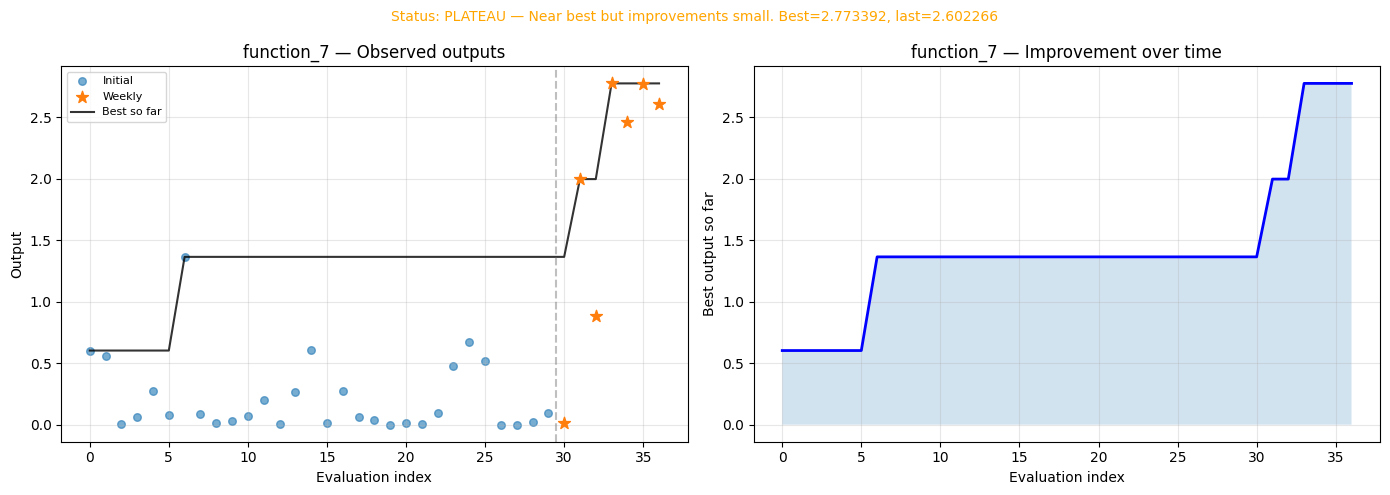

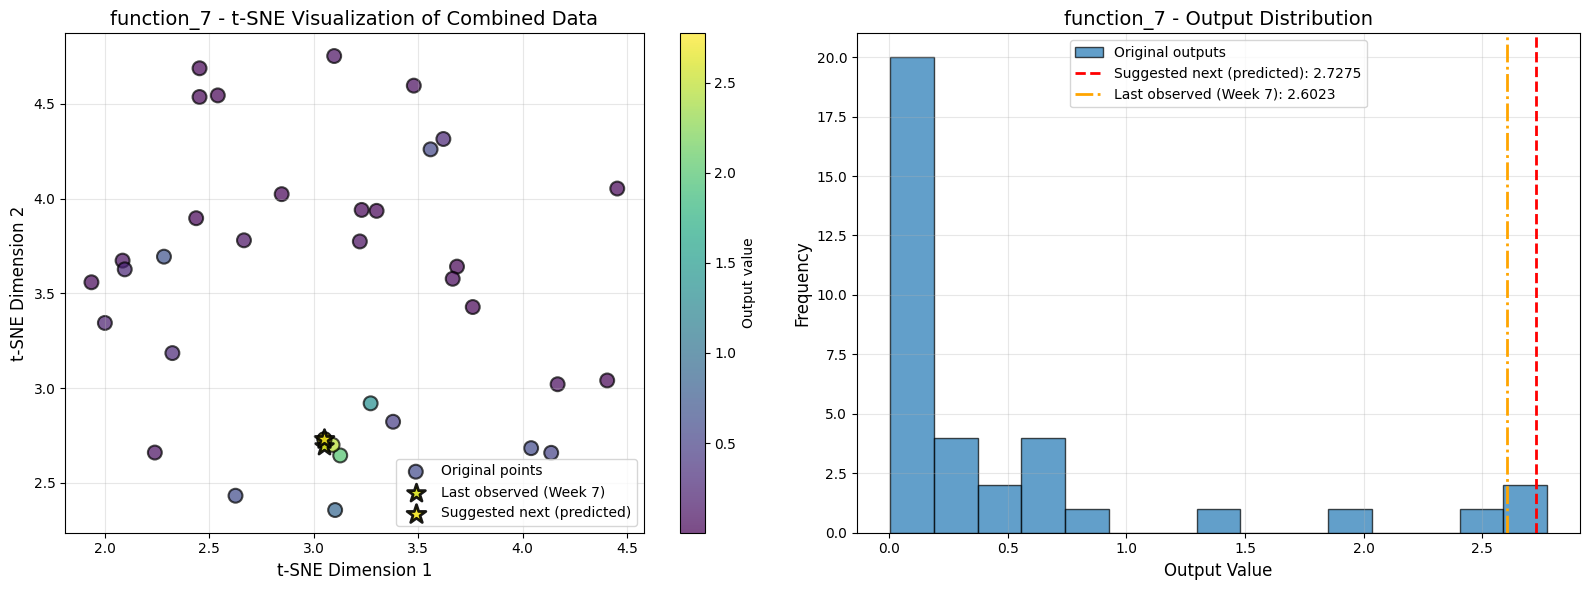


Function 8 — Progress and validation
--------------------------------------------------
  Status: IMPROVING
  Near best and still improving. Best=9.900834, last=9.891780


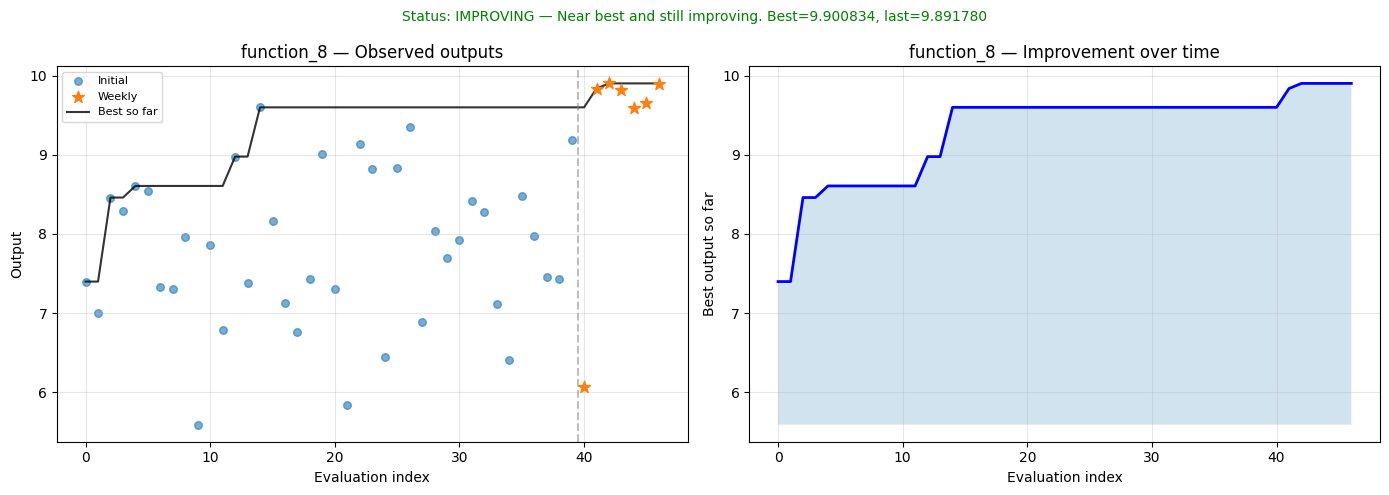

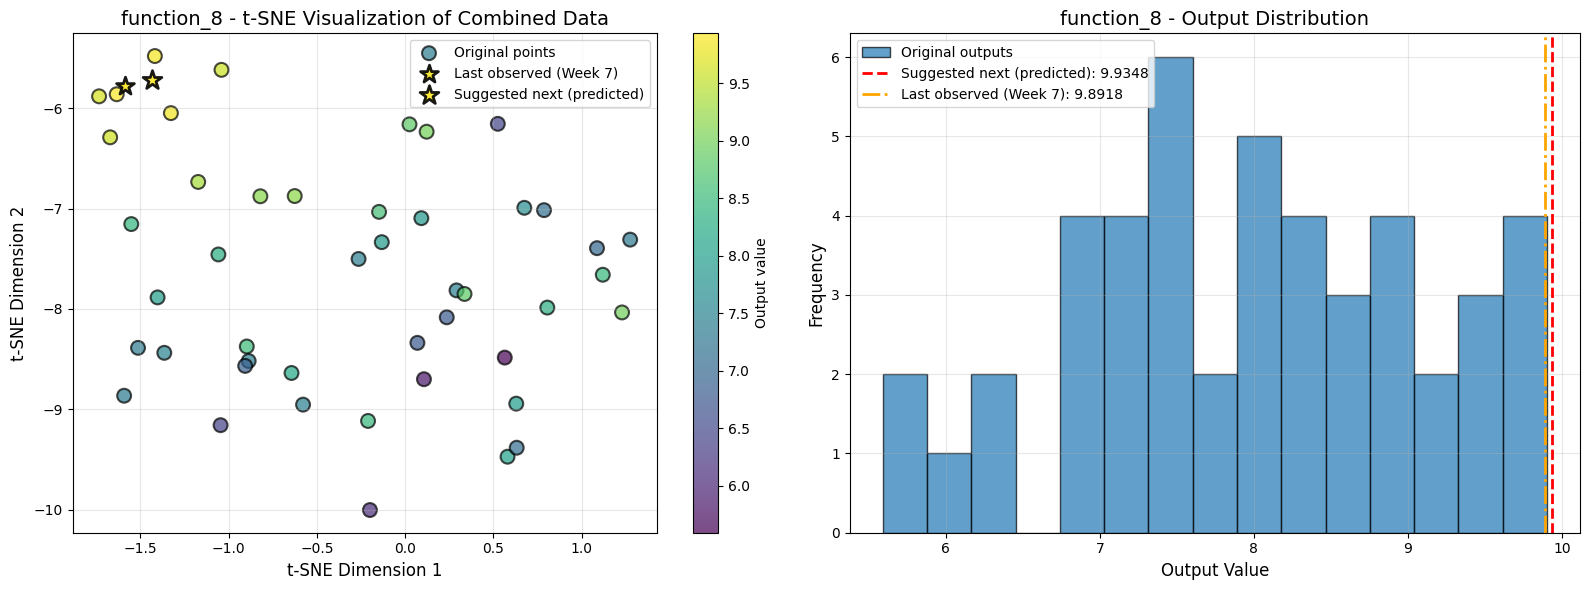

⚠️  At least one function flagged for review (plateau/stuck).


In [4]:
def validation_check(y, recent_window=3, close_tol_frac=0.01, min_improve_frac=0.001):
    """
    Check if we're improving over time (same idea as Bayesian notebook).
    Returns (status, message, flag) where flag=True means concerning.
    """
    y = np.asarray(y).ravel()
    n = len(y)
    if n < 2 or recent_window < 1:
        return "insufficient_data", "Need at least 2 points", True
    recent = y[-recent_window:]
    last = float(y[-1])
    best_overall = float(np.max(y))
    best_recent = float(np.max(recent))
    scale = max(abs(best_overall), 1e-12)
    close_tol = scale * close_tol_frac
    near_best = (best_overall - best_recent) <= close_tol
    if near_best:
        prev = float(y[-2]) if n >= 2 else last
        improve = (last - prev) / scale if scale > 0 else 0
        if improve >= min_improve_frac:
            return "improving", f"Near best and still improving. Best={best_overall:.6f}, last={last:.6f}", False
        else:
            return "plateau", f"Near best but improvements small. Best={best_overall:.6f}, last={last:.6f}", True
    trend = last - float(y[-recent_window])
    if trend >= 0:
        return "improving", f"Recent trend positive, moving toward best={best_overall:.6f}", False
    return "stuck", f"Recent trend negative. Best={best_overall:.6f}, recent_best={best_recent:.6f}", True


def plot_progress_and_validation(X, y, weeks_loaded, function_name, x_next, y_pred, figsize=(14, 5)):
    """Plot output vs evaluation index, best-so-far, and validation status."""
    n = len(y)
    n_initial = n - len(weeks_loaded)
    eval_index = np.arange(n)
    week_label = np.zeros(n, dtype=int)  # 0 = initial
    week_label[n_initial:] = np.array(weeks_loaded)
    best_so_far = np.maximum.accumulate(y)
    status, message, flag = validation_check(y)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    # Left: observed output vs index
    mask_init = week_label == 0
    ax1.scatter(eval_index[mask_init], y[mask_init], c='tab:blue', alpha=0.6, s=30, label='Initial')
    ax1.scatter(eval_index[~mask_init], y[~mask_init], c='tab:orange', s=80, marker='*', label='Weekly', zorder=5)
    ax1.plot(eval_index, best_so_far, 'k-', lw=1.5, alpha=0.8, label='Best so far')
    ax1.set_xlabel('Evaluation index')
    ax1.set_ylabel('Output')
    ax1.set_title(f'{function_name} — Observed outputs')
    ax1.legend(loc='best', fontsize=8)
    ax1.grid(True, alpha=0.3)
    ax1.axvline(n_initial - 0.5, color='gray', linestyle='--', alpha=0.5)
    # Right: best-so-far only (clear view of improvement)
    ax2.plot(eval_index, best_so_far, 'b-', lw=2, label='Best so far')
    ax2.fill_between(eval_index, np.min(y), best_so_far, alpha=0.2)
    ax2.set_xlabel('Evaluation index')
    ax2.set_ylabel('Best output so far')
    ax2.set_title(f'{function_name} — Improvement over time')
    ax2.grid(True, alpha=0.3)
    status_color = 'green' if status == 'improving' else 'orange' if status == 'plateau' else 'red'
    fig.suptitle(f'Status: {status.upper()} — {message}', fontsize=10, color=status_color)
    plt.tight_layout()
    plt.show()


# --- Function 7: progress plots and validation ---
print('Function 7 — Progress and validation')
print('-' * 50)
status7, msg7, flag7 = validation_check(y7)
print(f'  Status: {status7.upper()}')
print(f'  {msg7}')
plot_progress_and_validation(X7, y7, weeks7, 'function_7', x7_next, y7_pred)
# t-SNE: observed points + last point (prior) + suggested next (new)
last_idx7 = X7.shape[0] - 1
plot_tsne_with_distribution(
    X7[:-1], y7[:-1],
    x7_next, y7_pred,
    'function_7',
    prior_input=X7[last_idx7], prior_output=float(y7[last_idx7]),
    prior_point_label='Last observed (Week 7)',
    new_point_label='Suggested next (predicted)',
)
print()

# --- Function 8: progress plots and validation ---
print('Function 8 — Progress and validation')
print('-' * 50)
status8, msg8, flag8 = validation_check(y8)
print(f'  Status: {status8.upper()}')
print(f'  {msg8}')
plot_progress_and_validation(X8, y8, weeks8, 'function_8', x8_next, y8_pred)
last_idx8 = X8.shape[0] - 1
plot_tsne_with_distribution(
    X8[:-1], y8[:-1],
    x8_next, y8_pred,
    'function_8',
    prior_input=X8[last_idx8], prior_output=float(y8[last_idx8]),
    prior_point_label='Last observed (Week 7)',
    new_point_label='Suggested next (predicted)',
)
print('=' * 60)
if flag7 or flag8:
    print('⚠️  At least one function flagged for review (plateau/stuck).')
else:
    print('✓ Both functions showing healthy progress.')
print('=' * 60)


### Inputs/Outputs comparison tables (Functions 7 and 8)

Source, Input number, Output value, Distance to maximum input, Summary of progress. Proposed week 8 row uses the suggested next point and predicted score.

In [5]:
import importlib
import scripts.utils.distance_utils as distance_utils
importlib.reload(distance_utils)
from scripts.utils.distance_utils import make_inputs_outputs_table

# Function 7: 30 initial points (from initial_data)
n_initial_7 = 30
table7 = make_inputs_outputs_table(
    X7, y7, n_initial_7,
    x_proposed=x7_next,
    y_proposed=float(y7_pred),
)
print("Function 7")
display(table7)

# Function 8: 40 initial points (from initial_data)
n_initial_8 = 40
table8 = make_inputs_outputs_table(
    X8, y8, n_initial_8,
    x_proposed=x8_next,
    y_proposed=float(y8_pred),
)
print("Function 8")
display(table8)

Function 7


,Source,Input number,Output value,Distance to maximum input,Summary of progress
0,initial,1,0.604433,0.833521,Initial
1,initial,2,0.562753,1.032303,Initial
2,initial,3,0.007503,0.831097,Initial
3,initial,4,0.061424,0.874538,Initial
4,initial,5,0.273047,1.035823,Initial
5,initial,6,0.083747,0.904015,Initial
6,initial,7,1.364968,0.295922,Initial
7,initial,8,0.092645,0.676982,Initial
8,initial,9,0.017870,0.963091,Initial
9,initial,10,0.033565,0.960677,Initial


Function 8


,Source,Input number,Output value,Distance to maximum input,Summary of progress
0,initial,1,7.398721,1.345337,Initial
1,initial,2,7.005228,1.482762,Initial
2,initial,3,8.459481,1.351699,Initial
3,initial,4,8.284008,1.462972,Initial
4,initial,5,8.606117,1.299961,Initial
5,initial,6,8.541748,1.000141,Initial
6,initial,7,7.327435,1.508824,Initial
7,initial,8,7.299872,1.690706,Initial
8,initial,9,7.957875,1.436970,Initial
9,initial,10,5.592194,1.667751,Initial


## Step 3: Save Results to JSON Files

In [ ]:
# Create results directory if it doesn't exist
results_dir = Path('results')
results_dir.mkdir(exist_ok=True)

# Function 7 - Save to JSON
function7_result = {
    "function_name": "function_7",
    "next_point": x7_next.tolist(),
    "formatted": '-'.join([f'{x:.6f}' for x in x7_next]),
    "method": "pytorch_neural_network_gradient_optimization",
    "predicted_score": float(y7_pred),
    "epochs": epochs,
    "hidden": hidden,
    "lr": lr,
    "n_restarts": n_restarts,
    "max_iter": max_iter
}

function7_path = results_dir / 'function7_next_point.json'
with open(function7_path, 'w') as f:
    json.dump(function7_result, f, indent=2)
print(f'✓ Function 7 result saved to: {function7_path}')

# Function 8 - Save to JSON
function8_result = {
    "function_name": "function_8",
    "next_point": x8_next.tolist(),
    "formatted": '-'.join([f'{x:.6f}' for x in x8_next]),
    "method": "pytorch_neural_network_gradient_optimization",
    "predicted_score": float(y8_pred),
    "epochs": epochs,
    "hidden": hidden,
    "lr": lr,
    "n_restarts": n_restarts,
    "max_iter": max_iter
}

function8_path = results_dir / 'function8_next_point.json'
with open(function8_path, 'w') as f:
    json.dump(function8_result, f, indent=2)
print(f'✓ Function 8 result saved to: {function8_path}')

print('\n' + '=' * 60)
print('SUMMARY')
print('=' * 60)
print(f'Function 7: {function7_result["formatted"]}')
print(f'  Predicted score: {y7_pred:.6f}')
print(f'Function 8: {function8_result["formatted"]}')
print(f'  Predicted score: {y8_pred:.6f}')
print('=' * 60)
print('\nMethod: Gradient-based optimization (L-BFGS)')
print(f'  - {n_restarts} random restarts')
print(f'  - Up to {max_iter} gradient steps per restart')
print(f'  - More efficient than random sampling')

✓ Function 7 result saved to: results/function7_next_point.json
✓ Function 8 result saved to: results/function8_next_point.json

SUMMARY
Function 7: 0.074117-0.294798-0.418289-0.217241-0.306987-0.644886
  Predicted score: 2.727468
Function 8: 0.014868-0.230605-0.015162-0.067732-0.833455-0.445898-0.068456-0.378297
  Predicted score: 9.934760

Method: Gradient-based optimization (L-BFGS)
  - 25 random restarts
  - Up to 100 gradient steps per restart
  - More efficient than random sampling
